In [9]:
from owlready2 import *

# --- Création de l'ontologie ---
onto = get_ontology("http://exemple.org/famille.owl")

with onto:
    # --- Classes principales ---
    class Personne(Thing): pass
    class Sexe(Thing): pass
    
    # --- Instances de Sexe ---
    masculin = Sexe("masculin")
    feminin  = Sexe("feminin")
    
    # --- Propriétés de données ---
    class nom(DataProperty):
        domain = [Personne]
        range = [str]
    
    # --- Propriété de l'objet : sexe ---
    class sexe(ObjectProperty):
        domain = [Personne]
        range = [Sexe]
        functional = True  # chaque personne n'a qu'un sexe
    
    # --- Classes Homme / Femme ---
    class Homme(Personne):
        equivalent_to = [Personne & (sexe.value(masculin))]
    class Femme(Personne):
        equivalent_to = [Personne & (sexe.value(feminin))]
    
    # --- Individus Homme ---
    jacques = Homme("jacques")
    louis   = Homme("louis")
    pierre  = Homme("pierre")
    gerard  = Homme("gerard")
    jean    = Homme("jean")
    patrick = Homme("patrick")
    
    # --- Individus Femme ---
    monique = Femme("monique")
    germaine= Femme("germaine")
    yvette  = Femme("yvette")
    therese = Femme("therese")
    muriel  = Femme("muriel")
    sandrine= Femme("sandrine")
    astride = Femme("astride")
    
    # --- Relations parent / enfant ---
    class aEnfant(ObjectProperty): pass
    class aFille(aEnfant): pass
    class aFils(aEnfant): pass
    
    class aParent(ObjectProperty):
        inverse_property = aEnfant
    class aMere(aParent): pass
    class aPere(aParent): pass
    
    # --- Classes Parent, Mere, Pere ---
    class Parent(Personne):
        equivalent_to = [Personne & (aEnfant.some(Personne))]
    class Mere(Femme, Parent): pass
    class Pere(Homme, Parent): pass
    
    # --- Relations frère/soeur ---
    class aFrereSoeur(ObjectProperty):
        symmetric = True
        transitive = True
    class aSoeur(aFrereSoeur): pass
    class aFrere(aFrereSoeur): pass
    
    # --- Grand-parent / petit-enfant (via fonction Python) ---
    class aGrandParent(ObjectProperty): pass
    class aPetitEnfant(ObjectProperty):
        inverse_property = aGrandParent

# --- Définition des relations concrètes entre individus ---
# Exemples tirés du TP
jacques.aFils = [pierre, jean]
jacques.aFille = [monique]

louis.aFils = [pierre]
gerard.aFille = [therese]
patrick.aFils = [sandrine]
patrick.aFille = [muriel, astride]

# Relations frère/soeur
jacques.aFrereSoeur = [louis, pierre]
monique.aFrereSoeur = [yvette, germaine]

# --- Raisonnement ---
sync_reasoner()  # Lance HermiT/Pellet intégré dans Owlready2

# --- Fonctions utiles ---
def grands_parents(personne):
    gps = set()
    for parent in personne.aParent:
        gps.update(parent.aParent)
    return gps

def petits_enfants(personne):
    pe = set()
    for enfant in personne.aEnfant:
        pe.update(enfant.aEnfant)
    return pe

# --- Affichage des instances Homme/Femme ---
print("Tous les hommes :")
for h in Homme.instances():
    print("-", h.name)

print("\nToutes les personnes :")
for p in Personne.instances():
    print("-", p.name)

# --- Exemple : Grands-parents de Sandrine ---
print("\nGrands-parents de Sandrine :")
for gp in grands_parents(sandrine):
    print("-", gp.name)

# --- Exemple : Petits-enfants de Jacques ---
print("\nPetits-enfants de Jacques :")
for pe in petits_enfants(jacques):
    print("-", pe.name)

onto.save(file="famille.owl")

* Owlready2 * Running HermiT...
    java -Xmx2000M -cp /opt/homebrew/Caskroom/miniconda/base/envs/ece_env/lib/python3.10/site-packages/owlready2/hermit:/opt/homebrew/Caskroom/miniconda/base/envs/ece_env/lib/python3.10/site-packages/owlready2/hermit/HermiT.jar org.semanticweb.HermiT.cli.CommandLine -c -O -D -I file:////var/folders/s3/wngfkqh12mx2bdh4nq_l0_840000gn/T/tmpswanqby1


Tous les hommes :
- jacques
- louis
- pierre
- gerard
- jean
- patrick

Toutes les personnes :
- jacques
- louis
- pierre
- gerard
- jean
- patrick
- monique
- germaine
- yvette
- therese
- muriel
- sandrine
- astride

Grands-parents de Sandrine :

Petits-enfants de Jacques :


* Owlready2 * HermiT took 0.2418210506439209 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)


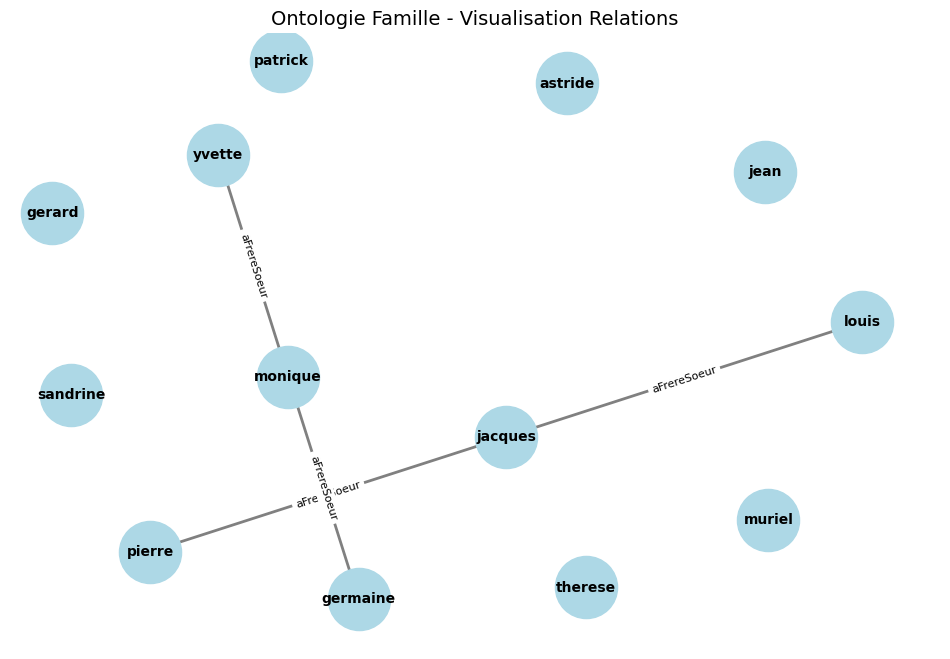

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# --- Création du graphe ---
G = nx.DiGraph()  # graphe orienté pour parent/enfant

# Ajouter les individus comme noeuds
for p in Personne.instances():
    G.add_node(p.name)

# Ajouter les relations parent/enfant
for parent in Personne.instances():
    if hasattr(parent, 'aEnfant'):
        for enfant in parent.aEnfant:
            G.add_edge(parent.name, enfant.name, label='aEnfant')

# Ajouter les relations frère/soeur (non orienté)
for fr in Personne.instances():
    if hasattr(fr, 'aFrereSoeur'):
        for sibling in fr.aFrereSoeur:
            if not G.has_edge(fr.name, sibling.name) and not G.has_edge(sibling.name, fr.name):
                G.add_edge(fr.name, sibling.name, label='aFrereSoeur')

# --- Visualisation ---
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)

# Noeuds
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Arêtes
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')

# Étiquettes sur les arêtes
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Ontologie Famille - Visualisation Relations", fontsize=14)
plt.axis('off')
plt.show()